# D_S3.0 — Why Saturation, Cubic, and Branch Fail the Global Relationship Gate

These three families (F07 Saturation(+), F21 Cubic, F23 Two Lines) have genuine relationships
but their MIC drops below 0.8 very quickly as noise increases.

This notebook visualizes MIC vs noise level for each, with scatterplot examples.

In [91]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

VARIANT_LEVELS = ['strong', 'standard', 'mild']
PLOT_VARIANT_LEVELS = ['strong', 'standard', 'mild']  # edit this list to show a subset

In [92]:
# ── Load data ──
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = ['case_id', 'family_id', 'family_name', 'snr', 'replicate', 'variant_level']
meta = cases[[c for c in meta_cols if c in cases.columns]].copy()
df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))
df = df[df['variant_level'].isin(VARIANT_LEVELS)].copy()

pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

cases_full = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

print(f'Total cases: {len(df):,}')
print(f'Available variant levels: {", ".join(VARIANT_LEVELS)}')
print(f'Current plot variants: {", ".join(PLOT_VARIANT_LEVELS)}')

Total cases: 156,780
Available variant levels: strong, standard, mild
Current plot variants: strong, standard, mild


In [93]:
# ── Plot function: MIC vs 1/SNR with scatterplot insets ──
MIC_THRESH = 0.8
OUTER_ROW_HSPACE = 0.42
SCATTER_GRID_HSPACE = 0.2
SCATTER_GRID_WSPACE = 0.08


def _format_snr_label(snr_val):
    if snr_val == float('inf'):
        return 'SNR = ∞'
    return f'SNR ≈ {snr_val:g}'


def plot_mic_vs_noise(fids, titles, suptitle, snr_examples=None, variant_levels=None):
    """
    One figure per family group.
    Main panel: MIC (y) vs 1/SNR (x, log scale), each dot = one case.
    Side panel: 2x2 example scatterplots at selected SNR levels.
    variant_levels: list drawn as separate rows, e.g. ['strong', 'standard', 'mild'].
    """
    selected_variants = PLOT_VARIANT_LEVELS if variant_levels is None else variant_levels
    if isinstance(selected_variants, str):
        selected_variants = [selected_variants]
    invalid_variants = [level for level in selected_variants if level not in VARIANT_LEVELS]
    if invalid_variants:
        raise ValueError(f'variant_levels contains invalid values: {invalid_variants}.')

    if snr_examples is None:
        snr_examples = [float('inf'), 500, 50, 10]
    if len(snr_examples) != 4:
        raise ValueError('snr_examples must contain exactly 4 values for the 2x2 scatter grid.')

    row_specs = [(fid, title, level) for fid, title in zip(fids, titles) for level in selected_variants]
    nrows = len(row_specs)
    fig = plt.figure(figsize=(10, 4.1 * nrows), constrained_layout=False)
    outer = fig.add_gridspec(
        nrows, 2,
        width_ratios=[2.0, 2.0],
        wspace=0.06,
        hspace=OUTER_ROW_HSPACE,
        top=0.94,
        bottom=0.06,
    )
    fig.suptitle(suptitle, fontsize=14, fontweight='bold')

    for row, (fid, title, variant_level) in enumerate(row_specs):
        fid_data = df[(df['family_id'] == fid) & (df['variant_level'] == variant_level)].copy()
        if fid_data.empty:
            raise ValueError(f'No rows found for {fid} at variant_level={variant_level!r}.')
        finite = fid_data[np.isfinite(fid_data['snr_val']) & (fid_data['snr_val'] > 0)].copy()
        finite['noise_ratio'] = 1.0 / finite['snr_val']

        # ── Main panel: MIC vs 1/SNR ──
        ax_main = fig.add_subplot(outer[row, 0])
        ax_main.scatter(finite['noise_ratio'], finite['MIC'],
                        s=12, alpha=0.35, color='#1976D2', edgecolors='none')

        mean_by_snr = finite.groupby('snr_val').agg(
            mic_mean=('MIC', 'mean'),
            noise_ratio=('noise_ratio', 'first')
        ).sort_values('noise_ratio')
        ax_main.plot(mean_by_snr['noise_ratio'], mean_by_snr['mic_mean'],
                     '-', color='#E53935', linewidth=2.0, label='Mean MIC', zorder=5)

        ax_main.axhline(MIC_THRESH, color='#333', linestyle='--', linewidth=1.2, alpha=0.7)
        ax_main.text(finite['noise_ratio'].min() * 1.2, MIC_THRESH + 0.02,
                     f'MIC = {MIC_THRESH}', fontsize=9, color='#333')

        ax_main.set_xscale('log')
        if row == nrows - 1:
            ax_main.set_xlabel('1 / SNR  (noise ratio, → more noise)', fontsize=10)
        else:
            ax_main.set_xlabel('')
        ax_main.set_ylabel('MIC', fontsize=10)
        ax_main.set_ylim(-0.02, 1.05)
        ax_main.set_title(f'{fid} — {title} — {variant_level.capitalize()}', fontsize=11, fontweight='bold')
        ax_main.legend(fontsize=9, loc='upper right')

        # Mark where mean crosses threshold.
        above = mean_by_snr[mean_by_snr['mic_mean'] >= MIC_THRESH]
        if len(above) > 0 and len(above) < len(mean_by_snr):
            last_above_nr = above['noise_ratio'].max()
            last_above_snr = 1.0 / last_above_nr
            ax_main.axvline(last_above_nr, color='#E53935', linestyle=':', alpha=0.5)
            ax_main.text(last_above_nr, 0.05,
                         f'SNR≈{last_above_snr:.0f}', fontsize=8, color='#E53935',
                         ha='center', rotation=90)

        if 500 in snr_examples and 500 in set(finite['snr_val']):
            ax_main.axvline(1 / 500, color='#F9A825', linestyle='-.', linewidth=1.1, alpha=0.8)
            ax_main.text(1 / 500, 0.98, 'SNR=500', fontsize=8, color='#8A6D00',
                         ha='center', va='top', rotation=90)

        # ── Side panel: example scatterplots in a 2x2 grid ──
        scatter_grid = outer[row, 1].subgridspec(
            2, 2,
            wspace=SCATTER_GRID_WSPACE,
            hspace=SCATTER_GRID_HSPACE,
        )

        for i, target_snr in enumerate(snr_examples):
            ax_sc = fig.add_subplot(scatter_grid[i // 2, i % 2])

            if target_snr == float('inf'):
                candidates = fid_data[fid_data['snr_val'] == float('inf')]
                snr_label = _format_snr_label(target_snr)
            else:
                finite_fid = fid_data[np.isfinite(fid_data['snr_val'])].copy()
                closest_snr = finite_fid.iloc[
                    (finite_fid['snr_val'] - target_snr).abs().argsort().iloc[0]
                ]['snr_val']
                candidates = fid_data[fid_data['snr_val'] == closest_snr]
                snr_label = _format_snr_label(closest_snr)

            rep0 = candidates[candidates['replicate'] == 0]
            if len(rep0) > 0:
                row_data = rep0.iloc[0]
            elif len(candidates) > 0:
                row_data = candidates.iloc[0]
            else:
                ax_sc.set_visible(False)
                continue

            idx = case_idx_by_id.get(row_data['case_id'])
            mic_val = row_data['MIC']
            color = '#1976D2' if mic_val >= MIC_THRESH else '#BDBDBD'

            if idx is not None:
                ax_sc.scatter(x_all[idx], y_all[idx], s=6, alpha=0.45,
                              color=color, edgecolors='none')

            scatter_title = snr_label  + f'   MIC={mic_val:.3f}'
            ax_sc.set_title(scatter_title, fontsize=8.5, fontweight='bold')
            ax_sc.set_xticks([])
            ax_sc.set_yticks([])

    plt.show()

## Saturation (F07)

The positive saturation curve is monotonic but flattens out — most of the x-range has near-zero slope.
Only a small portion of the curve carries the signal, so noise drowns it quickly.

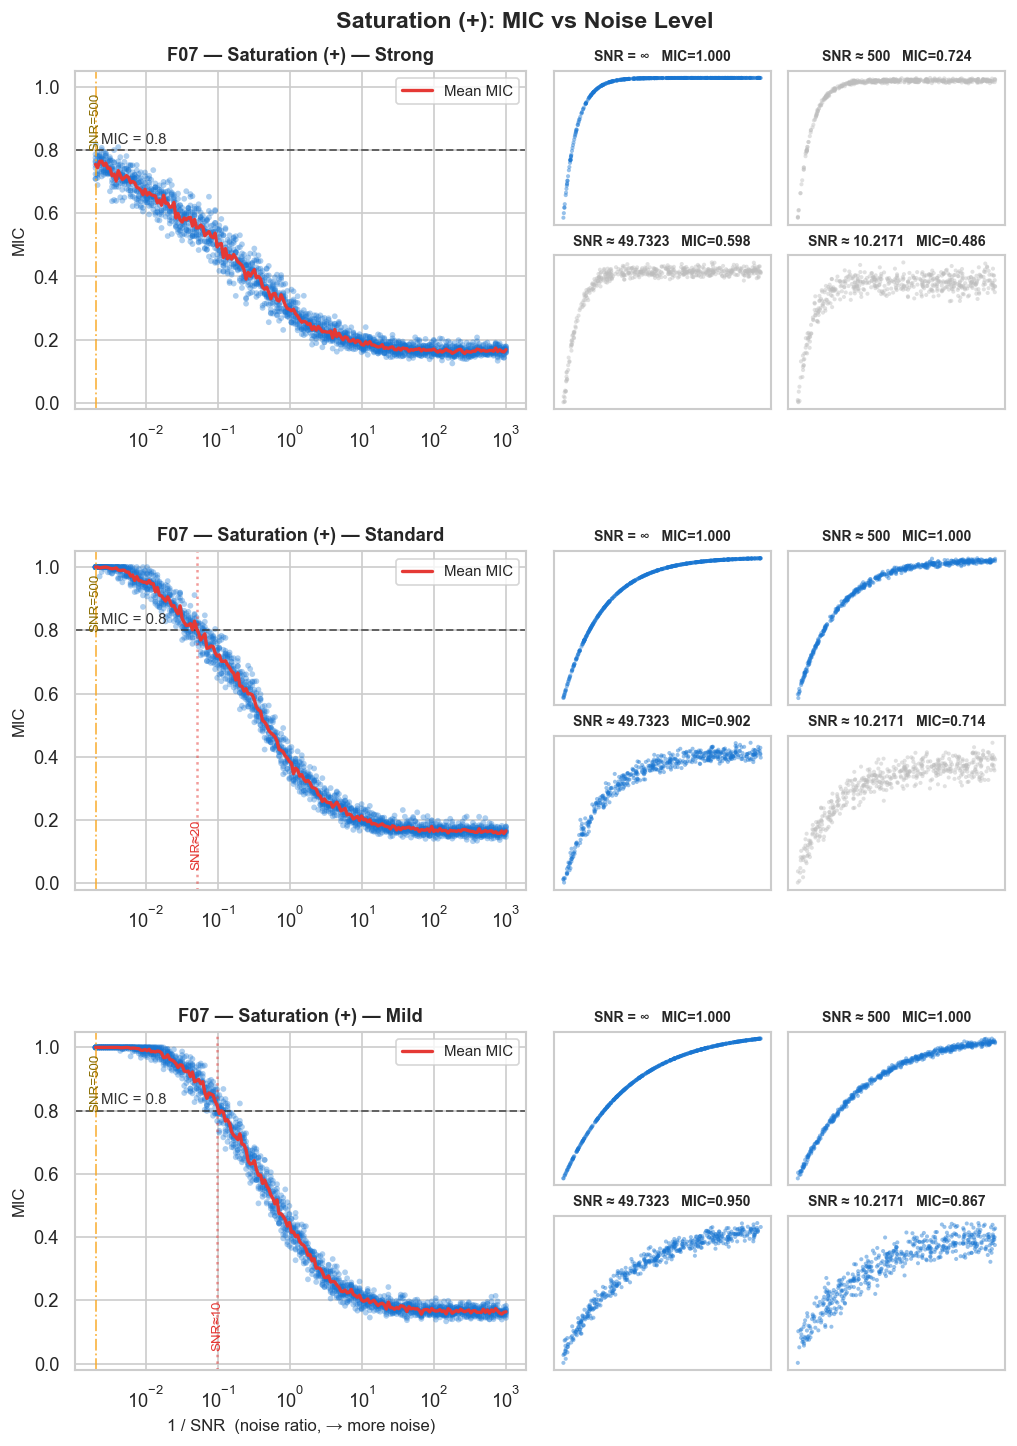

In [94]:
plot_mic_vs_noise(
    ['F07'],
    ['Saturation (+)'],
    'Saturation (+): MIC vs Noise Level'
)

## Cubic (F21)

Cubic has two turning points and moderate |r| ≈ 0.80. The non-monotonic sections
cause MIC to degrade faster than for simple monotonic curves.

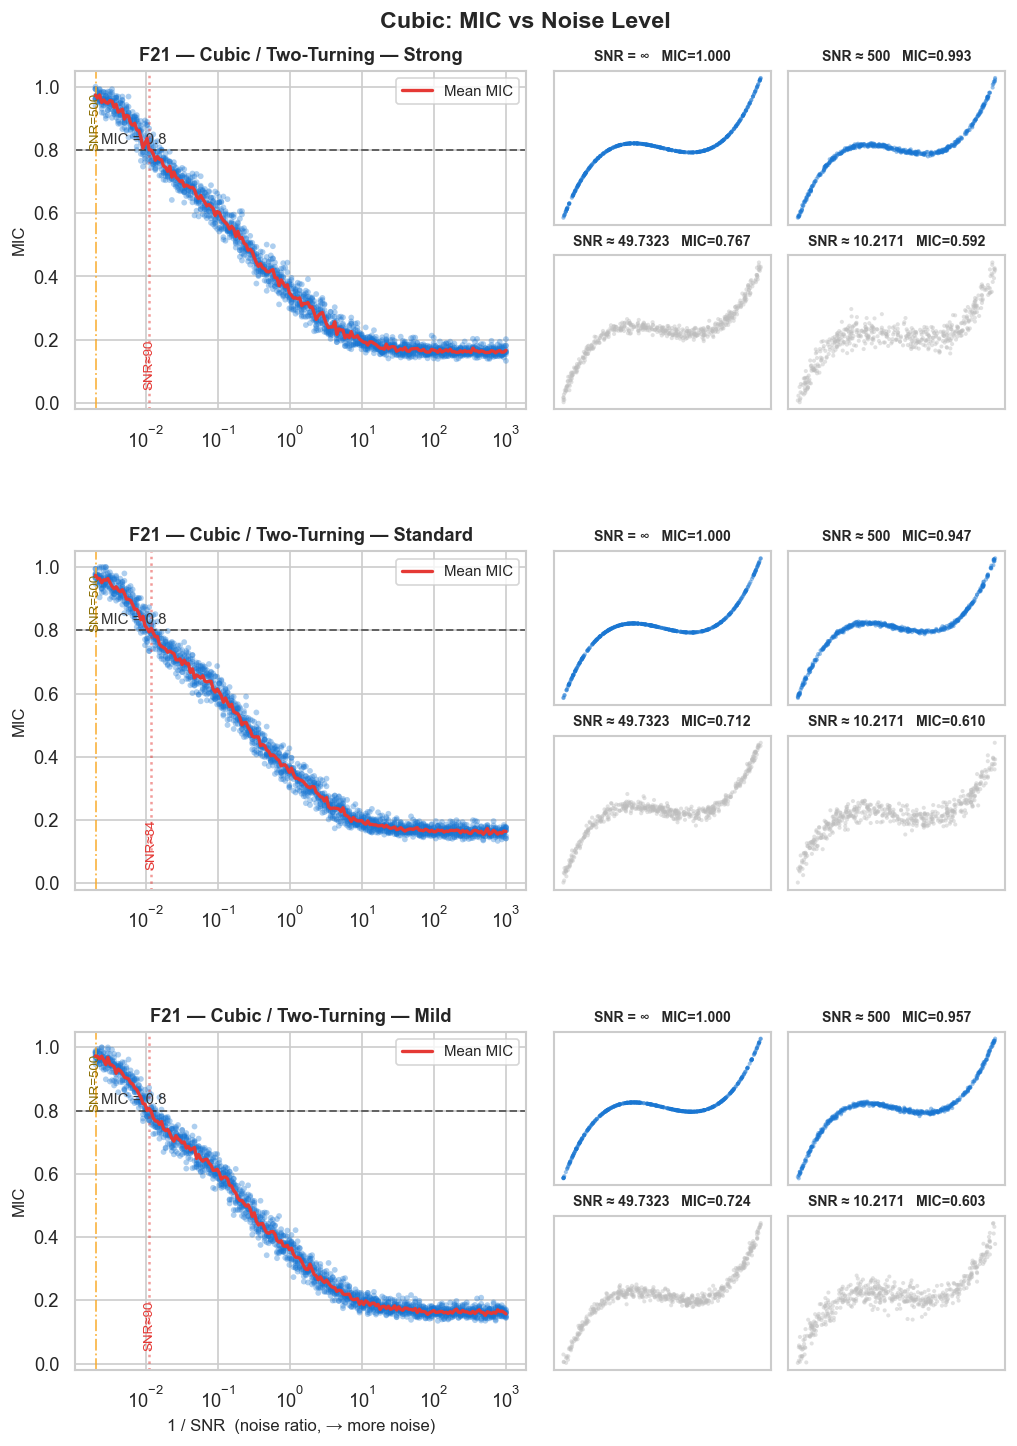

In [95]:
plot_mic_vs_noise(
    ['F21'],
    ['Cubic / Two-Turning'],
    'Cubic: MIC vs Noise Level'
)

## Two Lines / Branch (F23)

500 points split across two lines with different slopes. Globally |r| ≈ 0.50.
MIC sees the structure perfectly at SNR=∞ (0.988) but drops below 0.8 immediately
at SNR=500 — the two-line boundary blurs with even minimal noise.

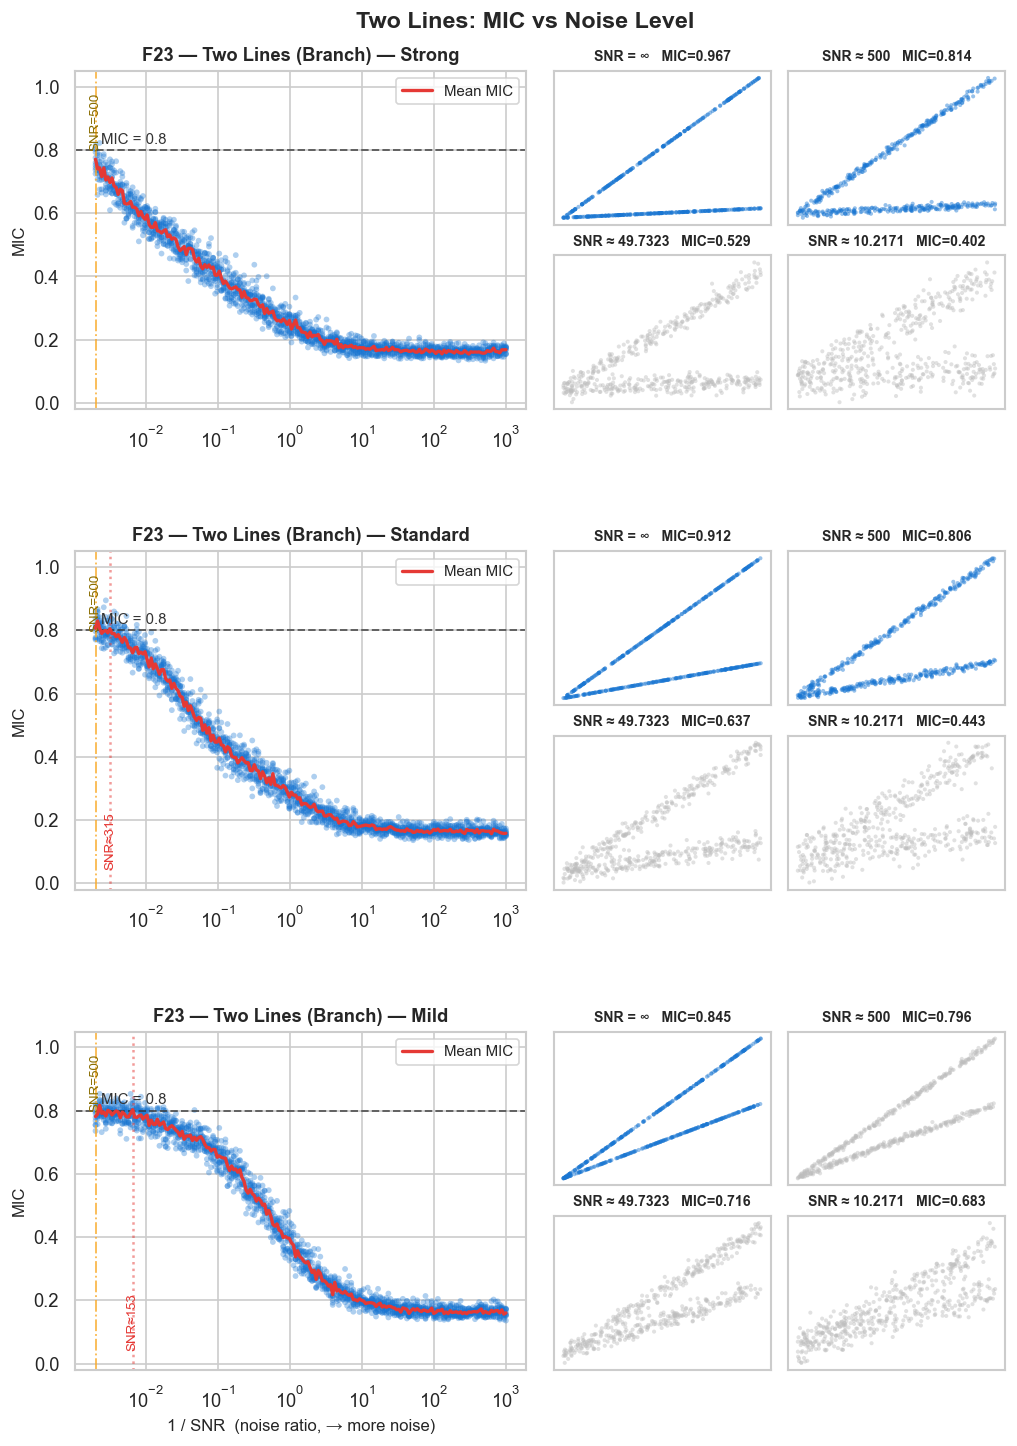

In [96]:
plot_mic_vs_noise(
    ['F23'],
    ['Two Lines (Branch)'],
    'Two Lines: MIC vs Noise Level'
)

## Summary

| Family | MIC at SNR=∞ | Drops below 0.8 at | Root cause |
|--------|-------------|-------------------|------------|
| F07 Sat(+) | 1.000 | SNR ≈ 500 | Signal concentrated in small x-range |
| F21 Cubic | 1.000 | SNR ≈ 50 | Two turning points reduce MIC sensitivity |
| F23 Two Lines | 0.988 | SNR ≈ 500 | Points split across branches, \|r\| ≈ 0.5 |